In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, LSTM, Embedding
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
df = pd.read_csv("/content/encoded_data_interpretability.csv")

df.head()

,Host,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,...,pos_515,pos_516,pos_517,pos_518,pos_519,pos_520,pos_521,pos_522,pos_523,pos_524
0,5,10,7,12,13,17,9,9,4,17,...,15.0,19.0,8.0,15.0,5.0,5.0,3.0,16.0,8.0,9.0
1,5,10,7,12,13,17,9,9,4,17,...,15.0,19.0,8.0,15.0,5.0,5.0,3.0,16.0,8.0,9.0
2,5,10,7,12,13,17,9,9,4,17,...,15.0,19.0,8.0,15.0,5.0,5.0,3.0,16.0,8.0,9.0
3,2,10,7,12,13,17,9,9,4,17,...,15.0,19.0,8.0,14.0,5.0,5.0,3.0,16.0,8.0,9.0
4,2,10,7,12,13,17,9,9,4,17,...,15.0,19.0,8.0,15.0,5.0,5.0,3.0,16.0,8.0,9.0


In [5]:
y = df["Host"]
x = df.drop("Host" , axis = 1)

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense, Input, Dropout, Reshape, Softmax, Multiply, Lambda
from tensorflow.keras.models import Model

xtrain = np.nan_to_num(xtrain, nan=0.0, posinf=0.0, neginf=0.0)
xtrain = xtrain.astype('int32')

sequence_length = xtrain.shape[1]
vocab_size = int(np.max(xtrain)) + 1
n_classes = int(df['Host'].nunique())

inputs = Input(shape=(sequence_length,), dtype='int32')
x = Embedding(input_dim=vocab_size, output_dim=128, input_length=sequence_length, mask_zero=True)(inputs)
gru_out = GRU(128, return_sequences=True)(x)
scores = Dense(1)(gru_out)
scores = Reshape((sequence_length,))(scores)
att_weights = Softmax(axis=1)(scores)
att_weights = Reshape((sequence_length, 1))(att_weights)
context_vector = Multiply()([gru_out, att_weights])
context_vector = Lambda(lambda t: tf.reduce_sum(t, axis=1))(context_vector)
x = Dense(64, activation='relu')(context_vector)
x = Dropout(0.3)(x)
outputs = Dense(n_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_with_attention = Model(inputs=inputs, outputs=[outputs, att_weights])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'reshape' (of type Reshape) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [28]:
model.fit(xtrain, ytrain, epochs=5, validation_data=(xtest, ytest))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'reshape' (of type Reshape) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.6189 - loss: 1.5756

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'reshape' (of type Reshape) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


61/61 ━━━━━━━━━━━━━━━━━━━━ 65s 962ms/step - accuracy: 0.6195 - loss: 1.5721 - val_accuracy: 0.7310 - val_loss: 0.9565
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.6754 - loss: 1.1933 - val_accuracy: 0.7310 - val_loss: 0.9452
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 936ms/step - accuracy: 0.6794 - loss: 1.1499 - val_accuracy: 0.7310 - val_loss: 0.9602
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 82s 933ms/step - accuracy: 0.6779 - loss: 1.1542 - val_accuracy: 0.7310 - val_loss: 0.8754
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 917ms/step - accuracy: 0.7629 - loss: 0.9278 - val_accuracy: 0.8357 - val_loss: 0.6630


In [30]:
print(classification_report(ytest, model.predict(xtest).argmax(axis=1)))

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        79
           1       0.00      0.00      0.00         4
           2       0.89      0.98      0.93       356
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00        11
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         7
           8       0.00      0.00      0.00        21
           9       0.00      0.00      0.00         4

    accuracy                           0.84       487
   macro avg       0.15      0.17      0.16       487
weighted avg       0.75      0.84      0.79       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
xtrain = np.nan_to_num(xtrain, nan=0.0, posinf=0.0, neginf=0.0)
xtrain = xtrain.astype('int32')

sequence_length = xtrain.shape[1]
vocab_size = int(np.max(xtrain)) + 1
n_classes = int(df['Host'].nunique())

inputs = Input(shape=(sequence_length,), dtype='int32')
x = Embedding(input_dim=vocab_size, output_dim=128, input_length=sequence_length, mask_zero=True)(inputs)
x = LSTM(128)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(n_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
model.fit(xtrain, ytrain, epochs=5, validation_data=(xtest, ytest))

Epoch 1/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6211 - loss: 1.5452 - val_accuracy: 0.7310 - val_loss: 0.9501
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7268 - loss: 1.0236 - val_accuracy: 0.8501 - val_loss: 0.6896
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8151 - loss: 0.8401 - val_accuracy: 0.8891 - val_loss: 0.5048
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8591 - loss: 0.6744 - val_accuracy: 0.8932 - val_loss: 0.4799
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8553 - loss: 0.6422 - val_accuracy: 0.8953 - val_loss: 0.4491


In [33]:
print(classification_report(ytest, model.predict(xtest).argmax(axis=1)))

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        79
           1       0.00      0.00      0.00         4
           2       0.90      1.00      0.95       356
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00        11
           6       0.00      0.00      0.00         2
           7       1.00      0.29      0.44         7
           8       0.66      1.00      0.79        21
           9       0.00      0.00      0.00         4

    accuracy                           0.90       487
   macro avg       0.36      0.30      0.30       487
weighted avg       0.86      0.90      0.87       487



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
model.save("/content/lstm_rabies.h5")

In [47]:
lstm_layer = model.get_layer(index=1)
intermediate_model = Model(inputs=model.input, outputs=lstm_layer.output)

hidden_states = intermediate_model.predict(xtest)
print(hidden_states.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
(487, 524, 128)


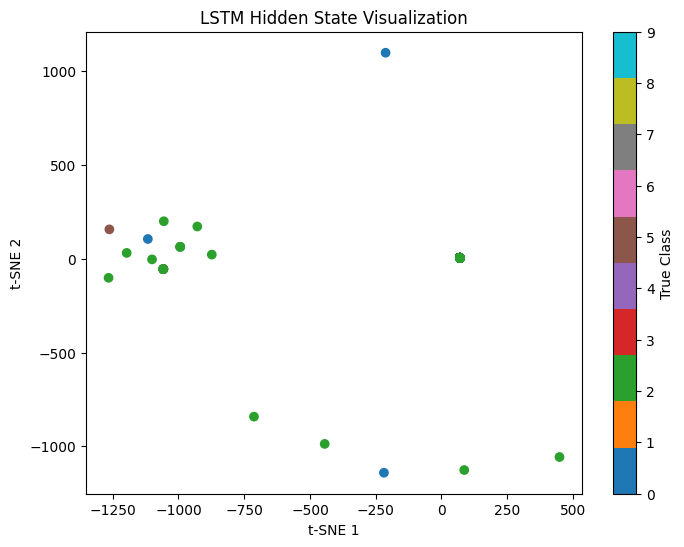

In [48]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

hidden_last = hidden_states[:, -1, :]
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
hidden_2d = tsne.fit_transform(hidden_last)

plt.figure(figsize=(8,6))
plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=ytest, cmap='tab10')
plt.colorbar(label='True Class')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('LSTM Hidden State Visualization')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


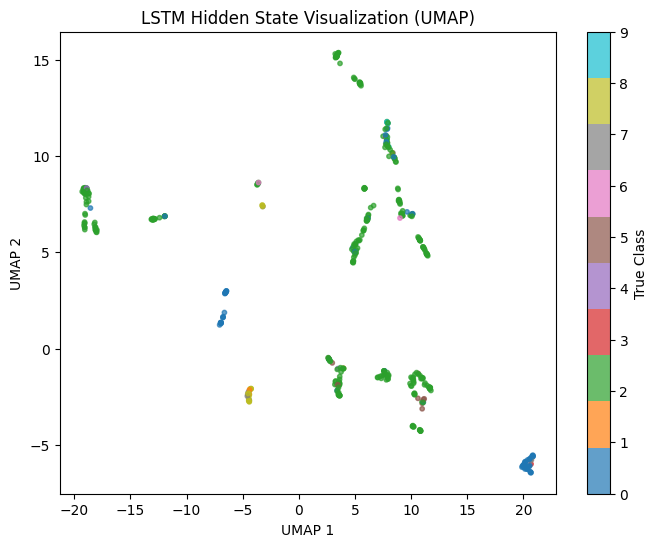

In [56]:
import umap

hidden_flat = hidden_states.mean(axis=1)
reducer = umap.UMAP(n_components=2, random_state=42)
hidden_2d = reducer.fit_transform(hidden_flat)

plt.figure(figsize=(8,6))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=ytest, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, label='True Class')
plt.title('LSTM Hidden State Visualization (UMAP)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()